In [69]:
import numpy as np
import keras
from colorama.ansi import set_title
from keras import utils
from keras import constraints
from keras.datasets import cifar10
import matplotlib.pyplot as plt
from numpy.ma.core import argmax
from sklearn.metrics import confusion_matrix

In [139]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

## Normalize

In [140]:
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)
x_train /= 255.0
x_test /= 255.0

## One-hot encoding outputs

In [141]:
y_train = utils.to_categorical(y_train)
y_test = utils.to_categorical(y_test)

In [118]:
class_num = y_test.shape[1]

# Build model

In [74]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, (3, 3), padding="same", input_shape=x_train.shape[1:], activation="relu"))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Flatten())
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(32, activation="relu"))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(class_num, activation="softmax"))

## Compile model

In [75]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,834 (1.50 MB)

 Trainable params: 393,258 (1.50 MB)

 Non-trainable params: 576 (2.25 KB)

# Training the model

In [76]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15, batch_size=64)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - accuracy: 0.3215 - loss: 1.9374 - val_accuracy: 0.5423 - val_loss: 1.2867
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.5371 - loss: 1.2977 - val_accuracy: 0.6486 - val_loss: 0.9930
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.6262 - loss: 1.0568 - val_accuracy: 0.6746 - val_loss: 0.9391
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.6699 - loss: 0.9465 - val_accuracy: 0.7104 - val_loss: 0.8314
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.7015 - loss: 0.8620 - val_accuracy: 0.7456 - val_loss: 0.7275
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.7205 - loss: 0.7938 - val_accuracy: 0.7503 - val_loss: 0.7207
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.7356 - loss: 0.7444 - val_accuracy: 0.7599 - val_loss: 0.7036
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.7534 - loss: 0.7037 - 

<Axes: >

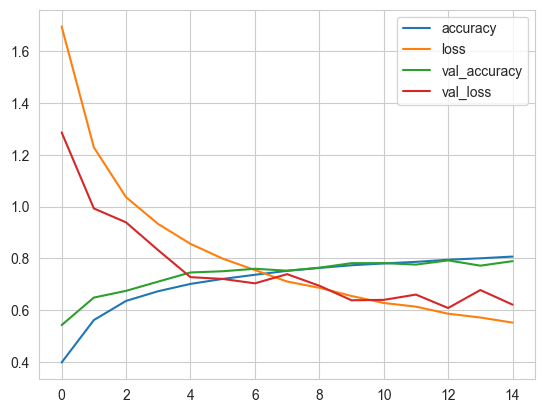

In [77]:
import pandas as pd

pd.DataFrame(history.history).plot()

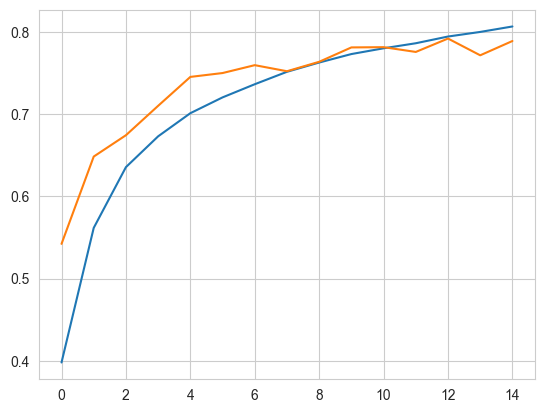

In [78]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()

## Save and Load model

In [79]:
model.save("CNN_cifar10.keras")

In [142]:
model2 = keras.models.load_model("models/CNN_cifar10.keras")

labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Predicting test data and checking model performance

In [145]:
pred = model2.predict(x_test[0:1])[0]
pred = np.argmax(pred)
act = np.argmax(y_test[0])
print(labels[pred], pred)
print(labels[act], act)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
cat 3
cat 3


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


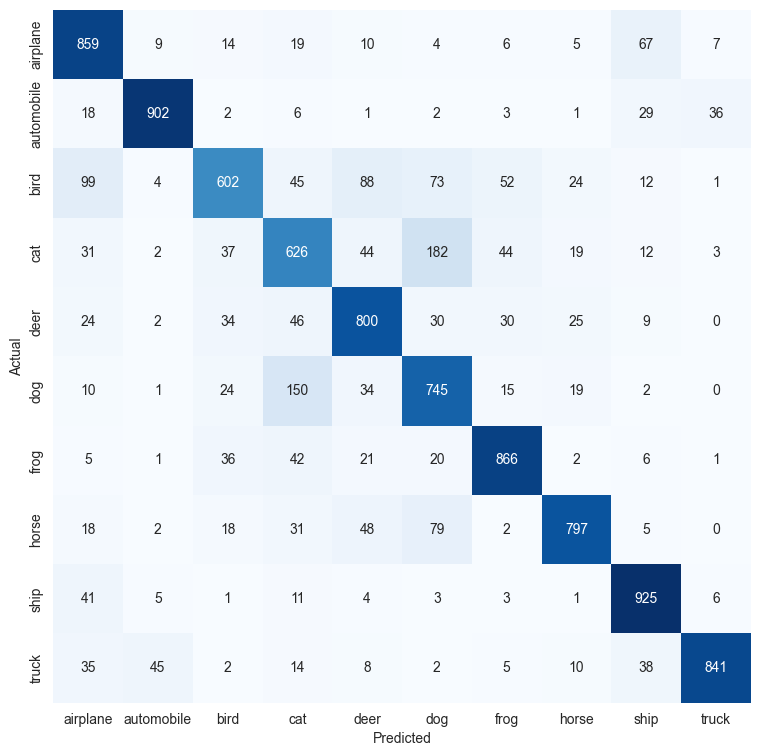

In [146]:
import seaborn as sns

predictions = model2.predict(x_test)

predictions = np.argmax(predictions, axis=1)
y_test_comp = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_comp, prediction)

plt.figure(figsize=(9, 9))
sns.heatmap(cm, cbar=False, xticklabels=labels, yticklabels=labels, fmt="d", annot=True, cmap=plt.cm.Blues)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

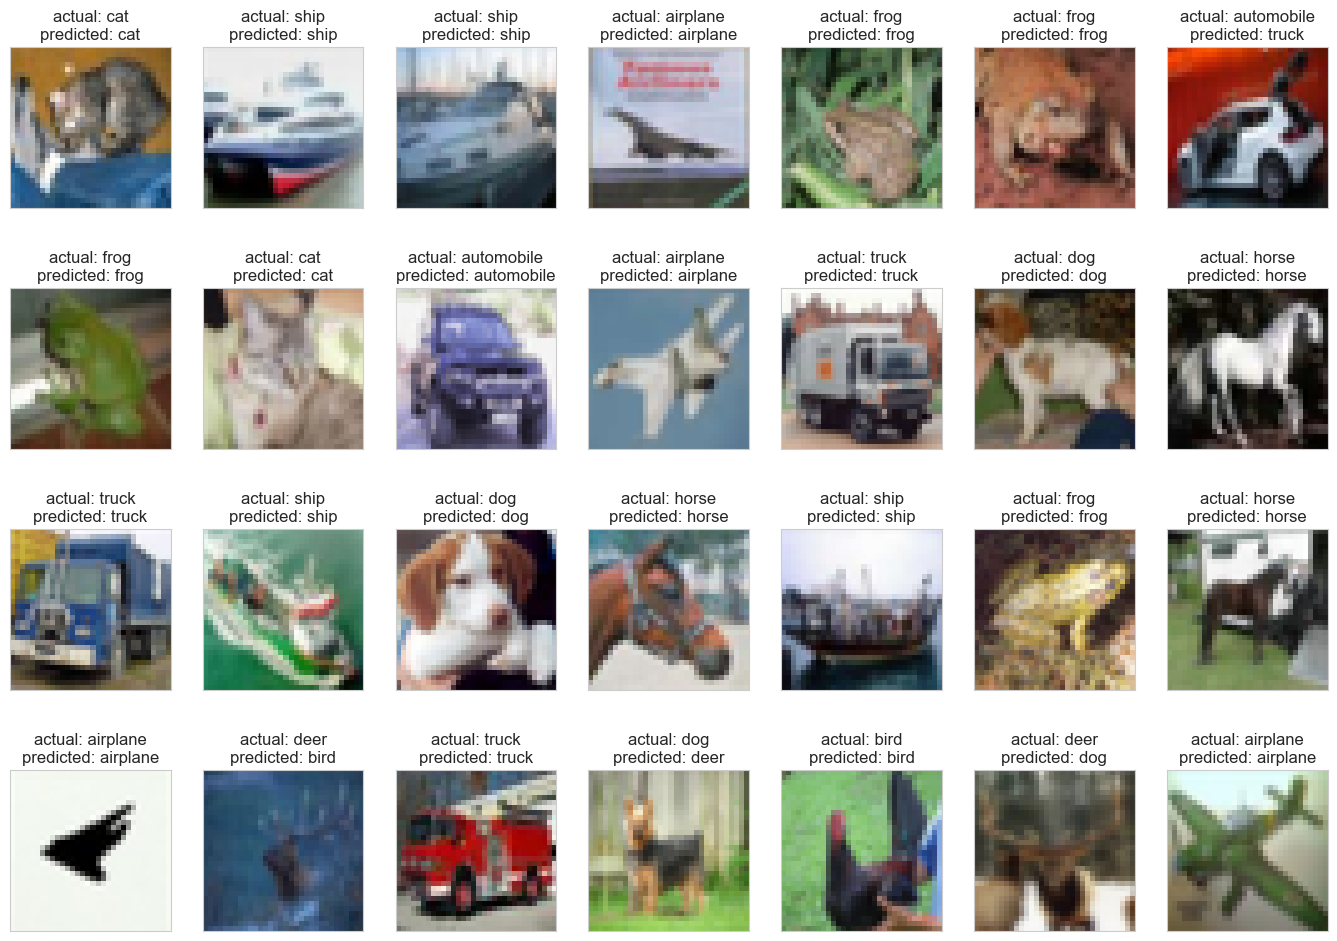

In [155]:
y_test_comp = y_test_comp.astype(int)
predictions = predictions.astype(int)
fig, imgs = plt.subplots(ncols=7, nrows=4, sharex=False, sharey=True, figsize=(17, 12))
index = 0
for i in range(4):
    for j in range(7):
        imgs[i, j].set_title("actual: " + labels[y_test_comp[index]] + '\n' + "predicted: " + labels[predictions[index]])
        imgs[i, j].imshow(x_test[index], cmap="gray")
        imgs[i, j].get_xaxis().set_visible(False)
        imgs[i, j].get_yaxis().set_visible(False)
        index += 1
plt.show()